# Codveda Technologies — Level 2, Task 1
## Logistic Regression for Binary Classification

**Dataset:** Telecom Churn

### Objectives
1. Preprocess the churn dataset
2. Train a Logistic Regression classifier
3. Tune important hyperparameters using `GridSearchCV`
4. Use cross-validation to select the best model
5. Evaluate the final model using classification metrics
6. Interpret coefficients as odds ratios

### Professional modeling principle
The test set is kept untouched until the final evaluation. Hyperparameters are selected using cross-validation on the training data only.

## 1. Import Required Libraries

In [15]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load the Dataset



In [16]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DATA_PATH = "datasets/churn-bigml-80.csv"

df = pd.read_csv("/content/churn-bigml-80.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 2,666
Columns: 20


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 3. Initial Data Inspection

In [17]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
display(df["Churn"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0



Duplicate rows:
0

Target distribution:


,count
Churn,
False,2278
True,388


## 4. Remove Duplicate Observations

In [18]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows removed: {duplicates}")
print(f"New dataset shape: {df.shape}")

Duplicate rows removed: 0
New dataset shape: (2666, 20)


## 5. Define Features and Target

`Churn` is the binary target. Logistic Regression is distance-sensitive, so numerical features **must** be scaled or the largest-magnitude features will dominate the decision boundary regardless of actual relevance.

In [19]:
# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

TARGET_COLUMN = "Churn"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['State', 'International plan', 'Voice mail plan']

Numerical features:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


## 6. Train/Test Split

A stratified split keeps the churn class distribution approximately consistent across training and testing data.

In [20]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (2132, 19)
Testing set:  (534, 19)


## 7. Build the Preprocessing Pipeline

Numerical features are median-imputed and standardized. Categorical features are mode-imputed and one-hot encoded.

In [21]:
# ============================================================
# 7. PREPROCESSING PIPELINE
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

## 8. Build the Logistic Regression Pipeline

In [22]:
# ============================================================
# 8. LOGISTIC REGRESSION PIPELINE
# ============================================================

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=2000
            )
        )
    ]
)

## 9. Hyperparameter Tuning with Grid Search

The hyperparameters are selected using **5-fold cross-validation** on the training set.

We tune:
- `C` — inverse regularization strength (smaller = stronger regularization)
- `penalty` — L1 (sparse, feature-selecting) vs L2 (shrinkage) regularization

`solver="liblinear"` is required to support both penalty types in this grid. The test set is not used during tuning.

In [23]:
# ============================================================
# 9. GRID SEARCH
# ============================================================

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:")
print(grid_search.best_params_)

print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.4f}")

Best hyperparameters:
{'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Best cross-validation F1 score: 0.4115


## 10. Evaluate the Best Model on the Test Set

In [24]:
# ============================================================
# 10. FINAL TEST EVALUATION
# ============================================================

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.8502
Precision: 0.4773
Recall   : 0.2692
F1 Score : 0.3443
ROC-AUC  : 0.7408

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       456
           1       0.48      0.27      0.34        78

    accuracy                           0.85       534
   macro avg       0.68      0.61      0.63       534
weighted avg       0.82      0.85      0.83       534



## 11. Confusion Matrix

,Predicted No Churn,Predicted Churn
Actual No Churn,433,23
Actual Churn,57,21


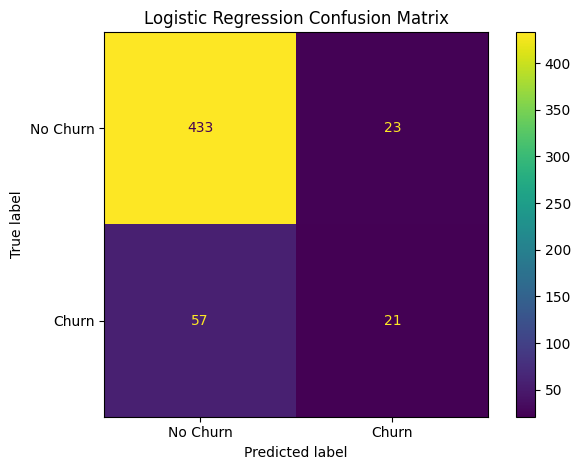

In [25]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

display(
    pd.DataFrame(
        cm,
        index=["Actual No Churn", "Actual Churn"],
        columns=["Predicted No Churn", "Predicted Churn"]
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. ROC Curve

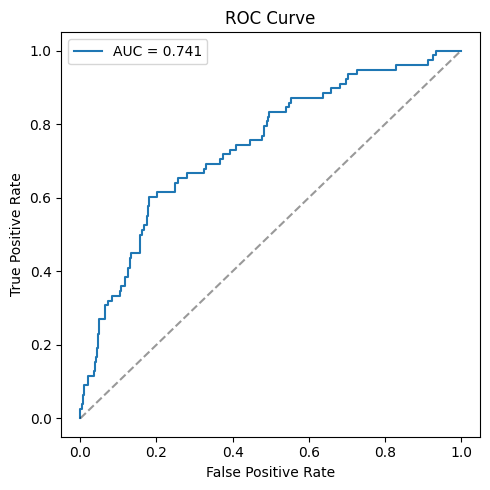

In [26]:
# ============================================================
# 12. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Coefficient Interpretation (Odds Ratios)

In logistic regression, `exp(coefficient)` gives the multiplicative change in the **odds** of the positive class for a one-unit increase in that (scaled) feature. An odds ratio of 1 means no effect; above 1 increases churn odds; below 1 decreases them.

Because categorical variables are one-hot encoded, individual categories appear as separate features.

In [27]:
# ============================================================
# 13. COEFFICIENT / ODDS RATIO INTERPRETATION
# ============================================================

fitted_preprocessor = best_model.named_steps["preprocessor"]
logreg_classifier = best_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = logreg_classifier.coef_[0]

odds_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Odds Ratio": np.exp(coefficients)
    })
    .sort_values("Odds Ratio", ascending=False)
    .reset_index(drop=True)
)

display(odds_df.head(15))

,Feature,Coefficient,Odds Ratio
0,categorical__International plan_Yes,1.689933,5.419117
1,categorical__State_TX,1.647361,5.193258
2,categorical__State_MT,1.224989,3.404128
3,categorical__State_MI,1.005253,2.732598
4,categorical__State_MS,1.003581,2.728034
5,categorical__State_SC,0.984934,2.677636
6,categorical__State_NJ,0.984098,2.675396
7,categorical__State_WA,0.905283,2.472631
8,numerical__Customer service calls,0.835236,2.305358
9,categorical__State_MN,0.805087,2.236891


Look for `International plan_Yes` and `Customer service calls` near the top — these are the classically strong churn predictors in this dataset. If your top features look wildly different, double check the encoding order didn't get scrambled.

## 14. Final Summary

In [28]:
# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("=" * 65)
print("LEVEL 2 - TASK 1: LOGISTIC REGRESSION SUMMARY")
print("=" * 65)

print("Best parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest CV F1 Score: {grid_search.best_score_:.4f}")

print("\nFinal Test Metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")

print("\nTop 5 features by odds ratio:")
display(odds_df.head(5))

print("=" * 65)

LEVEL 2 - TASK 1: LOGISTIC REGRESSION SUMMARY
Best parameters:
  classifier__C: 100
  classifier__penalty: l1
  classifier__solver: liblinear

Best CV F1 Score: 0.4115

Final Test Metrics:
  Accuracy : 0.8502
  Precision: 0.4773
  Recall   : 0.2692
  F1 Score : 0.3443
  ROC-AUC  : 0.7408

Top 5 features by odds ratio:


,Feature,Coefficient,Odds Ratio
0,categorical__International plan_Yes,1.689933,5.419117
1,categorical__State_TX,1.647361,5.193258
2,categorical__State_MT,1.224989,3.404128
3,categorical__State_MI,1.005253,2.732598
4,categorical__State_MS,1.003581,2.728034
